# PyTorch Neural Network Classificatio

In [38]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

## 1. Make classification data and get it ready

In [39]:
n_samples = 1002
X,y = make_circles(n_samples,noise=0.04,random_state=42)
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75088749  0.22897322]
 [-0.74593671  0.15576535]
 [-0.5282855  -0.52766419]
 [-0.41759385  0.67962533]
 [ 0.43460996 -0.90028782]]

First 5 y labels:
[1 1 1 1 0]


In [40]:
circles_df = pd.DataFrame({
    'X1'    : X[:,0],
    'X2'    : X[:,1],
    'label' : y
})
circles_df.head(10)

,X1,X2,label
0,0.750887,0.228973,1
1,-0.745937,0.155765,1
2,-0.528286,-0.527664,1
3,-0.417594,0.679625,1
4,0.434610,-0.900288,0
5,-0.479830,0.688223,1
6,-0.022350,0.804357,1
7,0.767177,0.143476,1
8,-0.781100,-0.235522,1
9,-0.112671,1.032323,0


In [41]:
circles_df.label.value_counts()

label
1    501
0    501
Name: count, dtype: int64

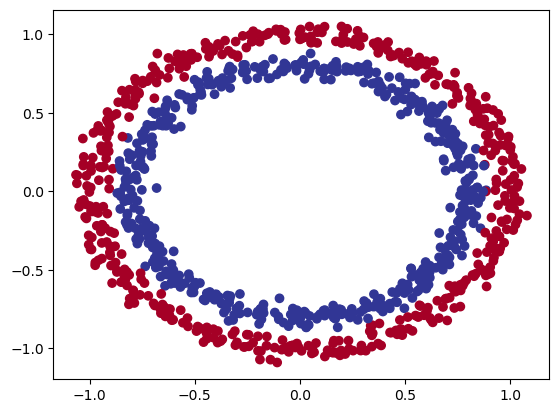

In [42]:
plt.scatter(x=X[:, 0],y=X[:, 1],c=y,cmap=plt.cm.RdYlBu);

In [43]:
### 1.2 Turn data into tensors and create train and test splits

In [44]:
X_tensor = torch.from_numpy(X).type(torch.float)
y_tensor = torch.from_numpy(y).type(torch.float)

X_tensor[:5],y_tensor[:5]

(tensor([[ 0.7509,  0.2290],
         [-0.7459,  0.1558],
         [-0.5283, -0.5277],
         [-0.4176,  0.6796],
         [ 0.4346, -0.9003]]),
 tensor([1., 1., 1., 1., 0.]))

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2,random_state=42) 
len(X_train), len(X_test), len(y_train), len(y_test)

(801, 201, 801, 201)

In [46]:
## 2. Building a model

In [48]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=5)
        self.layer_2 = nn.Linear(in_features=5,out_features=1)

    def forward(self,X):
        return self.layer_2(self.layer_1(X))

model_0  = CircleModelV0().to("cpu")
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [49]:
untrained_preds = model_0(X_test.to("cpu"))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 201, Shape: torch.Size([201, 1])
Length of test samples: 201, Shape: torch.Size([201])

First 10 predictions:
tensor([[0.2297],
        [0.2039],
        [0.2621],
        [0.2279],
        [0.1409],
        [0.1143],
        [0.1066],
        [0.0865],
        [0.2477],
        [0.1888]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 0., 0.])


In [50]:
### 2.1 Setup loss function and optimizer

In [51]:
loss_func = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),lr=0.2)

def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc =  (correct / len(y_pred)) * 100
    return acc

In [52]:
## 3. Train model